In [1]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import time


c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# Funciones básicas

In [2]:
    # Obtenemos la solución clásica por fuerza bruta
    def resolucion_clasica(Q_exacta, print_resultados = False):
        """
        Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO.
        verbose : bool       – Si True, imprime las mejores soluciones.

        Retorna
        -------
        sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
        """
        Q_exacta = np.array(Q_exacta)

        bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
        costs = []
        # this takes exponential time with the dimension of the QUBO
        for b in bitstrings:
            z = np.array(list(b), dtype=int)
            cost = z @ Q_exacta @ z
            costs.append(cost)
        zipped = zip(bitstrings, costs)
        sort_zipped = sorted(zipped, key=lambda x: x[1])

        if print_resultados:
            print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

        return sort_zipped
    # Ejecución de la función 
    #sort_zipped = resolucion_clasica(Q_exacta)


    # Determinamos la geometría de los átomos para Q
    def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
        """
        Optimiza las coordenadas atómicas para que las interacciones Rydberg
        reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO (simétrica).
        seed    : int        – Semilla para reproducibilidad.
        tol     : float      – Tolerancia del optimizador Nelder-Mead.
        maxiter : int        – Máximo de iteraciones.
        plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

        Retorna
        -------
        geometria : bloqade Program – Geometría lista para montar el programa.
        coords    : np.ndarray      – Coordenadas optimizadas (n×2).
        """
        Q = np.array(Q)
        device = pulser.DigitalAnalogDevice

        def evaluate_mapping(new_coords):
            new_coords = np.reshape(new_coords, (len(Q), 2))
            new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
            return np.linalg.norm(new_Q - Q)

        # Por si queremos cambiar el x0:
        if x0_func is not None:
            x0 = x0_func(A, Q)
        else:
            np.random.seed(seed)
            x0 = np.random.random(len(Q) * 2)

        #if random_x0 == True:
        #    np.random.seed(seed)
        #    x0 = np.random.random(len(Q) * 2)
        #elif random_x0 == False:
        #    C6 = 2 * np.pi * 862690
        #    d_init = (C6 / A) ** (1/6)
        #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

        res = minimize(
            evaluate_mapping,
            x0,
            method="Nelder-Mead",
            tol=tol,
            options={"maxiter": maxiter, "maxfev": None},
        )

        coords = np.reshape(res.x, (len(Q), 2))

        if plot:
            # Visualización Pulser
            #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
            #reg = pulser.Register(coord_dict)
            #reg.draw(
            #    blockade_radius=device.rydberg_blockade_radius(1),
            #    draw_graph=False,
            #    draw_half_radius=True,
            #)
            coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
            reg = pulser.Register(coord_dict)
            # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
            omega_max = 0.9 * np.min(-np.diag(Q))
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(omega_max),
                draw_graph=False,
                draw_half_radius=True,
            )
            print(f"Coordenadas optimizadas:\n{coords}")

        # Construcción Bloqade
        coordenadas = [tuple(pt) for pt in coords.tolist()]
        geometria = start.add_position(coordenadas)

        if plot:
            geometria.show()

        return geometria, coords
    # Ejecución de la función 
    #geometria, coords = construir_geometria(Q)


    def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                        sweep_time=11.0, plot=False, n_shots=1000):
        """
        Ejecuta la simulación de átomos neutros para un problema QUBO dado.

        Parámetros
        ----------
        Q             : array-like  – Matriz QUBO.
        geometria     : Register     – Geometría de átomos (Bloqade).
        sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
        A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
        omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.
        n_shots       : int          – Número de disparos de la simulación.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.

        Retorna
        -------
        prob_exito    : float        – Probabilidad de medir la solución correcta.
        counts_str    : dict         – {bitstring: conteos}.
        """
        # ── PASO 1: Detunings locales desde la diagonal de Q ──
        Q = np.array(Q)
        delta_local = -np.diag(Q)
        delta_end   = np.max(delta_local)
        escalas     = (delta_local / delta_end).tolist()

        # ── PASO 2: Parámetros de pulso ──
        omega_max = 0.9 * np.min(np.abs(delta_local))
        sweep_time= sweep_time
        durations             = [0.8, sweep_time, 0.8]
        rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
        rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

        # ── PASO 3: Simulación ──
        prog = (
            geometria
            .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
            .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
        )
        emu_prog = prog.bloqade.python().run(shots=n_shots)
        report   = emu_prog.report()
        if plot:
            report.show()


        # ── PASO 4: Análisis ──
        counts = report.counts()[0]
        counts_str = {
            "".join(str(b) for b in estado): n
            for estado, n in counts.items()
        }

        energia_minima   = sort_zipped[0][1]
        soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

        exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
        prob_exito = exitos / n_shots

        # ── PASO 5: Resultados ──
        if plot:
            print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
            print(f"  Conteos solución:   {exitos} / {n_shots}")
            counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
            colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
            plt.figure(figsize=(12, 5))
            plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
            plt.xlabel("Bitstrings")
            plt.ylabel("Conteos")
            plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            plt.xticks(rotation=90, fontsize=7)
            plt.tight_layout()
            plt.show()

        return prob_exito, counts_str
    # Ejecución de la función 
    #prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Gap mínimo

In [64]:
# from scipy.spatial.distance import pdist, squareform
# from scipy.sparse import diags, kron, identity, csr_matrix
# from scipy.sparse.linalg import eigsh
# import numpy as np


from scipy.spatial.distance import pdist, squareform
import numpy as np

def gap_minimo_evolucion(Q, coords, A, sweep_time=11.0,
                         n_puntos=80, n_autovalores=4, plot=False):
    """
    Calcula el gap espectral mínimo durante la evolución QAA.

    Reconstruye H_Ryd(t) con los mismos pulsos que resolver_qubo
    y diagonaliza en n_puntos instantes para obtener E_0(t), E_1(t)...
    El mínimo se busca solo en el tramo central (Omega = Omega_max),
    excluyendo los extremos donde el gap colapsa por degeneración del
    fundamental al apagarse el término transversal.

    Parámetros
    ----------
    Q            : matriz QUBO efectiva
    coords       : coordenadas atómicas (n×2) devueltas por construir_geometria
    A            : escala global (solo para etiquetas)
    sweep_time   : duración del tramo central del pulso [µs]
    n_puntos     : número de instantes en los que se diagonaliza
    n_autovalores: cuántos autovalores más bajos calcular

    Retorna
    -------
    delta_min    : gap espectral mínimo E_1 - E_0 en el tramo central
    t_star       : instante en que se alcanza
    espectro     : array (n_puntos, n_autovalores) con E_j(t) - E_0(t)
    """
    import pulser
    n = len(Q)
    C6 = pulser.DigitalAnalogDevice.interaction_coeff

    # Interacciones V_ij a partir de las distancias optimizadas
    V = squareform(C6 / pdist(coords) ** 6)

    # Detunings y pulsos (idénticos a resolver_qubo)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = delta_local / delta_end
    omega_max   = 0.9 * np.min(np.abs(delta_local))

    durations = np.array([0.8, sweep_time, 0.8])
    t_total   = durations.sum()
    t_breaks  = np.cumsum(np.r_[0.0, durations])

    omega_vals = np.array([0.0, omega_max, omega_max, 0.0])
    detun_vals = np.array([-delta_end, -delta_end, delta_end, delta_end])

    def piecewise(t, breaks, vals):
        return np.interp(t, breaks, vals)

    # Operadores Pauli sobre n qubits (base |g>=0, |r>=1)
    sx   = np.array([[0, 1], [1, 0]], dtype=complex)
    n_op = np.array([[0, 0], [0, 1]], dtype=complex)
    I2   = np.eye(2, dtype=complex)

    def op_on(op, i):
        ops = [I2] * n
        ops[i] = op
        out = ops[0]
        for k in range(1, n):
            out = np.kron(out, ops[k])
        return out

    Sx   = [op_on(sx,   i) for i in range(n)]
    N_op = [op_on(n_op, i) for i in range(n)]

    # H_int (constante, depende solo de geometría)
    H_int = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(n):
        for j in range(i+1, n):
            H_int += V[i, j] * (N_op[i] @ N_op[j])

    # Diagonalizar en n_puntos instantes
    ts = np.linspace(0, t_total, n_puntos)
    espectro = np.zeros((n_puntos, n_autovalores))
    niveles  = np.zeros((n_puntos, n_autovalores))


    for k, t in enumerate(ts):
        Omega_t = piecewise(t, t_breaks, omega_vals)
        Delta_t = piecewise(t, t_breaks, detun_vals)

        H = H_int.copy()
        for i in range(n):
            H += (Omega_t / 2.0) * Sx[i]
            H -= (escalas[i] * Delta_t) * N_op[i]

        evals = np.linalg.eigvalsh(H)
        espectro[k, :] = evals[:n_autovalores] - evals[0]
        niveles[k, :]  = evals[:n_autovalores]

    gaps = espectro[:, 1]

    # --- Mínimo SOLO en el tramo central (Omega = Omega_max) ---
    t_inicio_central = t_breaks[1]   # fin de la rampa de subida
    t_fin_central    = t_breaks[2]   # inicio de la rampa de bajada
    mask = (ts >= t_inicio_central) & (ts <= t_fin_central)

    gaps_validos = np.where(mask, gaps, np.inf)
    idx_min   = np.argmin(gaps_validos)
    delta_min = gaps[idx_min]
    t_star    = ts[idx_min]

    if plot:
        # Primera gráfica: espectro relativo E_j(t) - E_0(t)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 5))
        for j in range(1, n_autovalores):
            plt.plot(ts, espectro[:, j], label=f"$E_{j} - E_0$", alpha=0.8)
        # Sombrear tramo central (zona de búsqueda)
        plt.axvspan(t_inicio_central, t_fin_central, color='gray', alpha=0.08,
                    label="Tramo central ($\\Omega = \\Omega_{\\max}$)")
        plt.axvline(t_star, color='red', ls='--', alpha=0.6,
                    label=f"$t^* = {t_star:.2f}\\,\\mu s$")
        plt.axhline(delta_min, color='gray', ls=':', alpha=0.6,
                    label=f"$\\Delta_{{\\min}} = {delta_min:.2f}$")
        plt.xlabel("t [µs]")
        plt.ylabel("Energía relativa al fundamental [rad/µs]")
        plt.title(f"Espectro instantáneo (A={A}, B/A={B/A:.2f}, C/A={C/A:.2f})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Segunda gráfica: niveles absolutos E_j(t)
        plt.figure(figsize=(8, 5))
        for j in range(n_autovalores):
            plt.plot(ts, niveles[:, j], label=f"$E_{j}$", alpha=0.8)
        plt.axvspan(t_inicio_central, t_fin_central, color='gray', alpha=0.08,
                    label="Tramo central")
        plt.axvline(t_star, color='red', ls='--', alpha=0.6,
                    label=f"$t^* = {t_star:.2f}\\,\\mu s$")
        plt.xlabel("t [µs]")
        plt.ylabel("Energía [rad/µs]")
        plt.title(f"Niveles de energía (A={A})")
        plt.legend()
        plt.tight_layout()
        plt.show()


    return delta_min, t_star, espectro, niveles

# Grafos

In [3]:
Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0],
    ]).flatten()


Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()


Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()


Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B], 
    [0,      -3*B+C, A+2*B, 0,     0    ],  
    [0,       0,    -3*B+C, A+2*B, 0    ],  
    [0,       0,     0,    -4*B+C, A+2*B],  
    [0,       0,     0,     0,    -3*B+C],  
])
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
def x0_func_C4mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [ 0.0,             0.0 ],
        [ d,               0.0 ],
        [ d,               d   ],
        [ 0.0,             d   ],
        [-d*np.sqrt(3)/2,  d/2 ],
    ]).flatten()


Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()


Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
def x0_func_C5mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 = (4,5) en triángulo equilátero con x_3=(3,4) y x_4=(4,0)
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()


Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

# Resolución 1 caso

---Solución clásica: 
 [('00101', np.float64(-40.0)), ('01001', np.float64(-40.0)), ('01010', np.float64(-40.0)), ('10100', np.float64(-40.0)), ('00010', np.float64(-35.0)), ('10000', np.float64(-35.0))] 



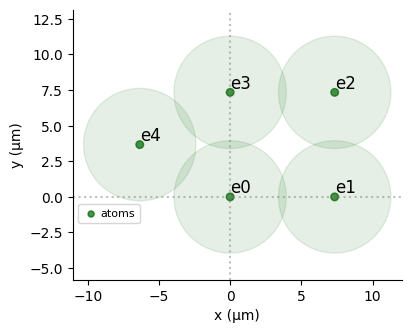

Coordenadas optimizadas:
[[-2.15902305e-04 -1.30650521e-03]
 [ 7.33763240e+00 -3.71889245e-04]
 [ 7.33886937e+00  7.33726538e+00]
 [ 1.06247296e-03  7.33617807e+00]
 [-6.34347103e+00  3.66854120e+00]]


-6343471.025602215 7338869.365504632 -1306.5052141197389 7337265.37654355


A=50, B=10.0, C=5.0  →  P(éxito) = 4.92%
  Soluciones válidas: ['00101', '01001', '01010', '10100']  (E = -40.000)
  Conteos solución:   492 / 10000


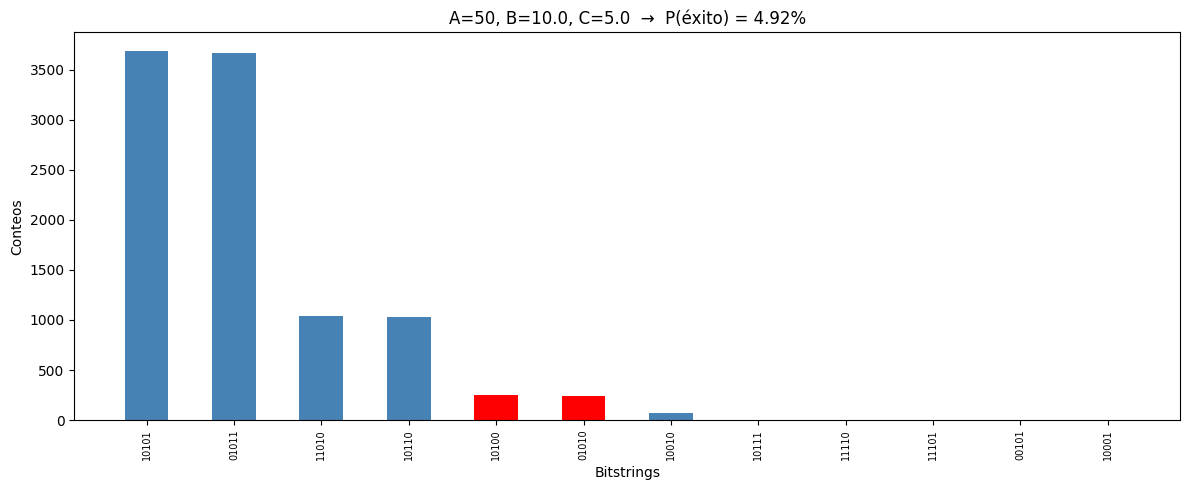

In [5]:
for k in [0.95]:
    A = A_solucion = 50#= 50 #= 10
    B = B_solucion = 0.2*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.1*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion
    Q_exacta_func = Q_exacta_func_C4mod
    Q_func = Q_func_C4mod
    x0_func = x0_func_C4mod

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

    A_values = [A]
    B_values = [B]
    C_values = [C]

---Solución clásica: 
 [('01', np.float64(-70.0)), ('10', np.float64(-70.0)), ('11', np.float64(-10.0)), ('00', np.float64(0.0))] 



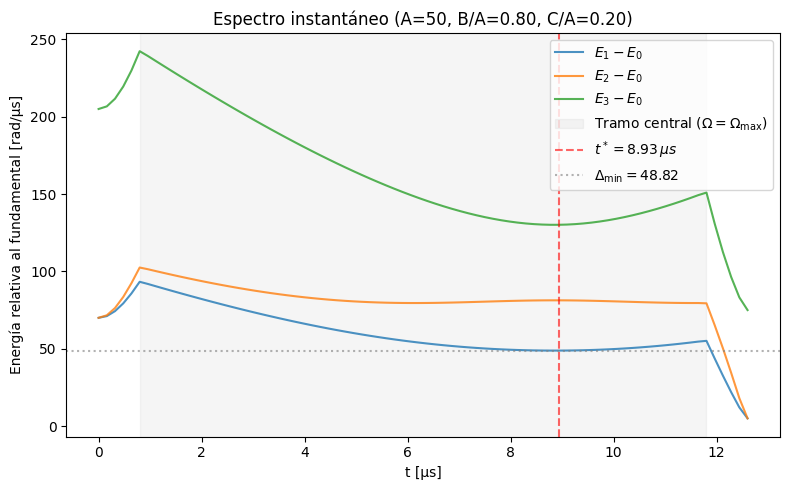

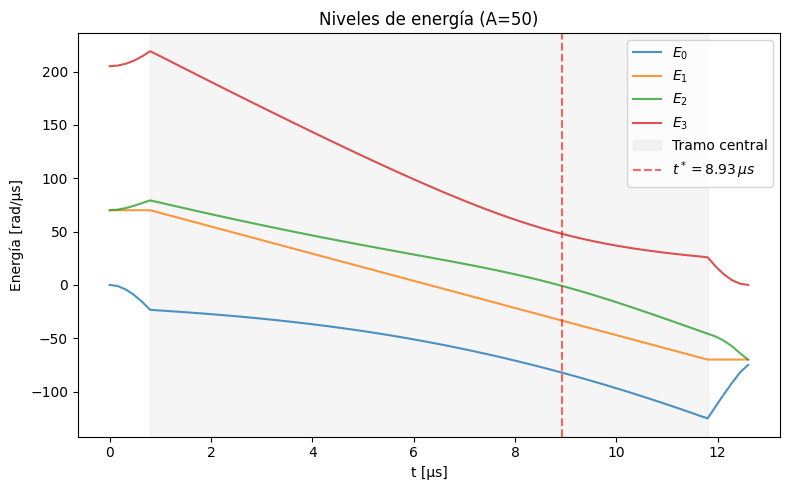

Δ_min = 48.817 rad/µs en t* = 8.93 µs
291.87788877606175 6610012.296020697 -46.389910252343014 38.50783407074289


A=50, B=40.0, C=10.0  →  P(éxito) = 32.30%
  Soluciones válidas: ['01', '10']  (E = -70.000)
  Conteos solución:   3230 / 10000


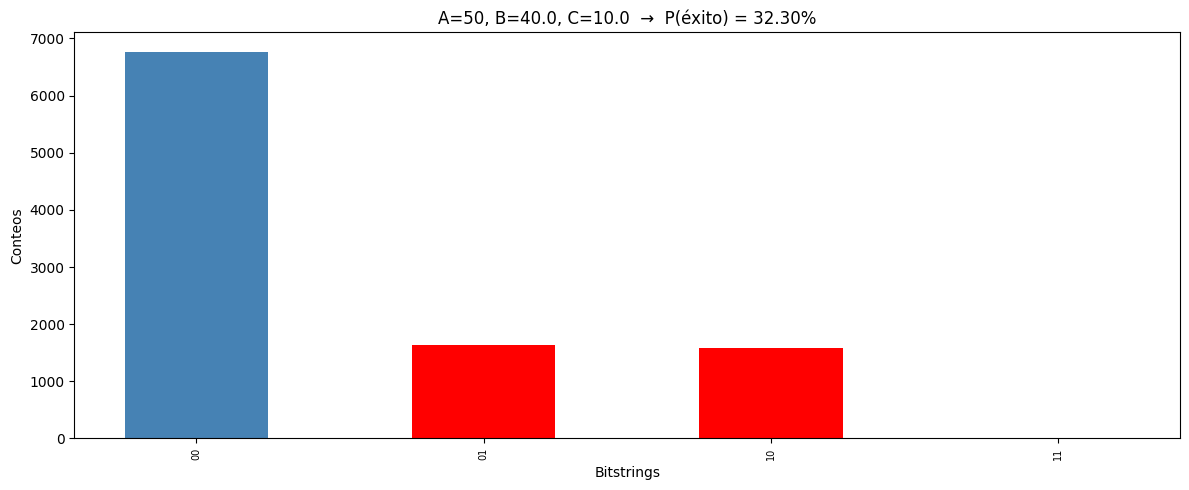

In [67]:
A = 50
B = 0.8 * A
C = 0.2* A
Q_func = Q_func_P3
Q_exacta_func = Q_exacta_func_P3
x0_func = x0_func_P3

sort_zipped = resolucion_clasica(Q_exacta_func(A, B, C), print_resultados=True)
Q = Q_func(A, B, C)
geometria, coords = construir_geometria(Q, plot=False, x0_func=x0_func)

# Gap mínimo durante la evolución
delta_min, t_star, espectro, niveles = gap_minimo_evolucion(
    Q, coords, A, sweep_time=11, n_puntos=80, plot=True
)
print(f"Δ_min = {delta_min:.3f} rad/µs en t* = {t_star:.2f} µs")




prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

# Barrido A


===== Grafo P3 =====
  A=  1.00  ->  P_éxito =  17.80%  |  t =  0.10 s
  A=  4.00  ->  P_éxito =  67.80%  |  t =  0.04 s
  A=  7.00  ->  P_éxito =  69.50%  |  t =  0.06 s
  A= 10.00  ->  P_éxito =  70.70%  |  t =  0.06 s
  A= 13.00  ->  P_éxito =  64.80%  |  t =  0.07 s
  A= 16.00  ->  P_éxito =  60.40%  |  t =  0.08 s
  A= 19.00  ->  P_éxito =  63.10%  |  t =  0.09 s
  A= 22.00  ->  P_éxito =  66.40%  |  t =  0.92 s
  A= 25.00  ->  P_éxito =  70.10%  |  t =  0.10 s
  A= 28.00  ->  P_éxito =  69.40%  |  t =  0.14 s
  A= 31.00  ->  P_éxito =  69.80%  |  t =  0.13 s
  A= 34.00  ->  P_éxito =  69.60%  |  t =  0.14 s
  A= 37.00  ->  P_éxito =  68.20%  |  t =  0.14 s
  A= 40.00  ->  P_éxito =  72.90%  |  t =  0.16 s
  A= 43.00  ->  P_éxito =  72.40%  |  t =  0.16 s
  A= 46.00  ->  P_éxito =  74.50%  |  t =  0.16 s
  A= 49.00  ->  P_éxito =  71.20%  |  t =  0.22 s
  A= 52.00  ->  P_éxito =  74.20%  |  t =  0.17 s
  A= 55.00  ->  P_éxito =  73.90%  |  t =  0.18 s
  A= 58.00  ->  P_éxito =  7

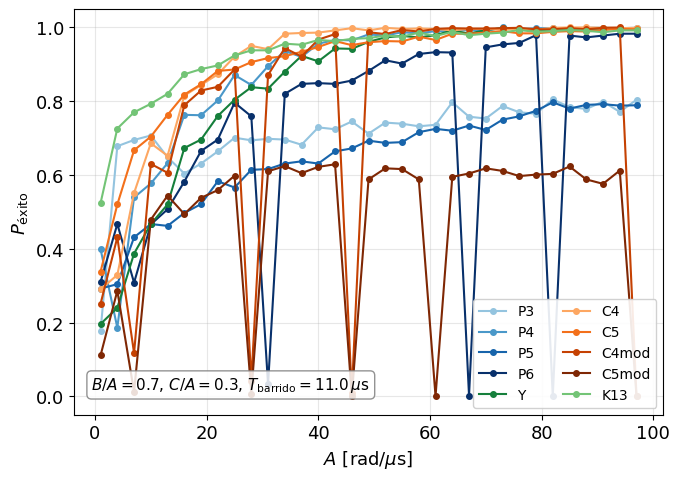

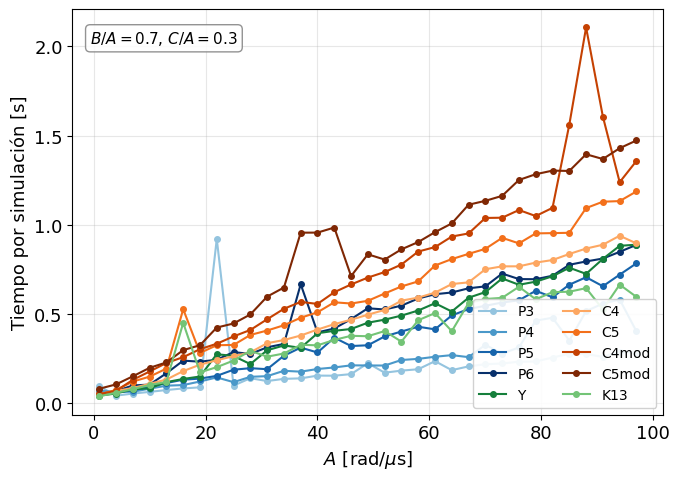

In [68]:
import csv
from pathlib import Path

#### Parámetros ####
ratio_B   = 0.7      # B/A
ratio_C   = 0.3       # C/A
A_values  = np.arange(1, 100, 3)
T_barrido = 11.0       # µs
n_shots   = 1000

CSV_PATH   = Path("barrido_A_results.csv")
RECALCULAR = True   # False -> solo cargar el CSV y graficar (sin volver a simular)

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
    "Y":  (Q_func_Y,  Q_exacta_func_Y,  x0_func_Y_horizontal),
    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    "C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
    "K13":   (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
}


#### Barrido: escribe filas al CSV de forma incremental ####
if RECALCULAR:
    # Cabecera + metadatos. Modo 'w' -> sobrescribe lo anterior.
    with open(CSV_PATH, 'w', newline='', encoding='utf-8') as f:
        f.write(f"# ratio_B={ratio_B}\n")
        f.write(f"# ratio_C={ratio_C}\n")
        f.write(f"# T_barrido={T_barrido}\n")
        f.write(f"# n_shots={n_shots}\n")
        f.write(f"# A_values={list(map(float, A_values))}\n")
        csv.writer(f).writerow(["grafo", "A", "P_exito", "tiempo_s"])   # <-- columna nueva

    t0_total = time.time()
    for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
        print(f"\n===== Grafo {nombre} =====")
        t0_grafo = time.time()
        for A in A_values:
            B = ratio_B * A
            C = ratio_C * A
            Q = Q_func_g(A, B, C)

            # Filtro para evitar casos con detuning no positivo
            if np.any(-np.diag(Q) <= 0):
                prob  = np.nan
                t_sim = np.nan
            else:
                try:
                    sort_zipped = resolucion_clasica(
                        Q_exacta=Q_exacta_func_g(A, B, C),
                        print_resultados=False,
                    )
                    geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func_g)

                    # --- cronómetro: solo la simulación ---
                    t0_sim = time.time()
                    prob, _ = resolver_qubo(
                        Q, geometria, sort_zipped, A, B, C,
                        sweep_time=T_barrido, plot=False, n_shots=n_shots,
                    )
                    t_sim = time.time() - t0_sim
                except Exception:
                    prob  = np.nan
                    t_sim = np.nan

            # Append inmediato -> el CSV refleja el progreso en tiempo real
            with open(CSV_PATH, 'a', newline='', encoding='utf-8') as f:
                csv.writer(f).writerow([
                    nombre, float(A),
                    '' if np.isnan(prob)  else f"{prob:.6f}",
                    '' if np.isnan(t_sim) else f"{t_sim:.4f}",
                ])
            prob_str = 'NaN' if np.isnan(prob)  else f'P_éxito = {prob*100:6.2f}%'
            t_str    = 'NaN' if np.isnan(t_sim) else f't = {t_sim:5.2f} s'
            print(f"  A={float(A):6.2f}  ->  {prob_str}  |  {t_str}")

        print(f"  [{nombre}] tiempo = {time.time()-t0_grafo:.1f} s")
    print(f"\nTiempo total: {time.time()-t0_total:.1f} s")
    print(f"Resultados guardados en: {CSV_PATH.resolve()}")


#### Cargar desde CSV (única fuente de verdad para el gráfico) ####
resultados_A = {}
tiempos_A    = {}
with open(CSV_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('grafo'):
            continue
        partes   = line.split(',')
        nombre   = partes[0]
        A_val    = float(partes[1])
        prob_str = partes[2] if len(partes) > 2 else ''
        t_str    = partes[3] if len(partes) > 3 else ''
        resultados_A[(nombre, A_val)] = float(prob_str) if prob_str else np.nan
        tiempos_A   [(nombre, A_val)] = float(t_str)    if t_str    else np.nan


#### Paleta consistente (misma que en el barrido en T) ####
import matplotlib.cm as cm

familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],
}

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)


#### Gráfico de probabilidad ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    probs = [resultados_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, probs, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.05,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$, $T_\text{{barrido}}={T_barrido}\,\mu$s',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()


#### Gráfico de tiempos ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    ts = [tiempos_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, ts, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.95,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

Outliers detectados y corregidos:
  P6:
    A =  31.0  ->    2.50%  =>   79.55%
    A =  67.0  ->    0.30%  =>   95.55%
    A =  82.0  ->    0.00%  =>   96.65%
  C4mod:
    A =   7.0  ->   10.90%  =>   53.10%
    A =  28.0  ->    5.90%  =>   85.85%
    A =  46.0  ->    2.10%  =>   98.25%
    A =  97.0  ->    0.00%  =>   99.90%
  C5mod:
    A =   7.0  ->    1.60%  =>   38.65%
    A =  28.0  ->    0.20%  =>   58.70%
    A =  46.0  ->    0.30%  =>   58.75%
    A =  61.0  ->    0.00%  =>   59.80%
    A =  97.0  ->    0.00%  =>   59.20%


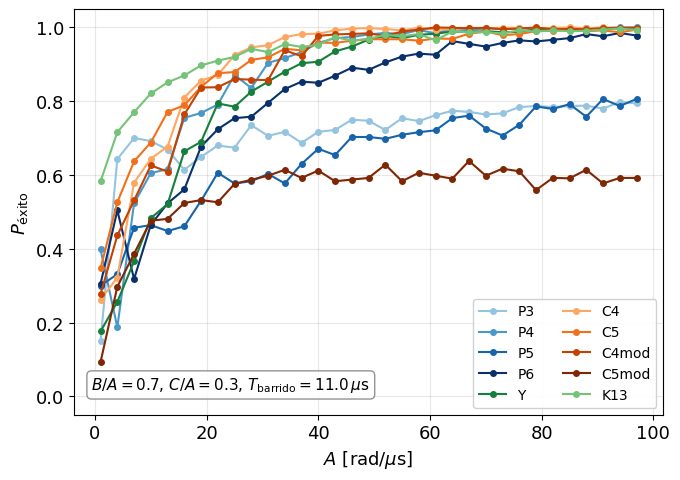

In [69]:
# ===================================================================
#  CELDA: re-grafica el barrido en A corrigiendo caídas espurias
# ===================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------- Datos crudos del barrido ----------
A_values = np.array([1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43,
                     46, 49, 52, 55, 58, 61, 64, 67, 70, 73, 76, 79, 82, 85,
                     88, 91, 94, 97], dtype=float)

datos = {
    'P3':   [15.0, 64.3, 70.0, 69.2, 66.9, 61.4, 64.9, 68.0, 67.4, 73.5, 70.6,
             71.7, 68.7, 71.7, 72.2, 75.0, 74.7, 72.2, 75.4, 74.6, 76.2, 77.4,
             77.1, 76.4, 76.7, 78.4, 78.7, 78.4, 78.7, 78.8, 78.0, 79.8, 79.4],
    'P4':   [39.8, 18.7, 52.3, 60.5, 61.6, 75.5, 76.8, 79.1, 87.1, 83.6, 90.4,
             91.7, 93.3, 95.8, 97.1, 97.4, 98.1, 98.5, 98.2, 99.3, 98.4, 99.6,
             99.2, 99.7, 99.7, 99.8, 99.7, 99.7, 99.5, 99.7, 99.8, 100.0, 100.0],
    'P5':   [30.0, 33.1, 45.7, 46.4, 44.8, 46.1, 53.0, 60.6, 57.7, 58.3, 60.3,
             57.7, 63.0, 67.1, 65.4, 70.3, 70.3, 69.8, 70.9, 71.6, 72.1, 75.4,
             76.1, 72.6, 70.7, 73.6, 78.6, 77.9, 79.2, 75.8, 80.6, 78.7, 80.6],
    'P6':   [30.5, 50.4, 31.8, 46.5, 52.3, 56.1, 67.7, 72.4, 75.4, 75.8,  2.5,
             83.3, 85.3, 85.0, 86.9, 89.1, 88.5, 90.5, 92.1, 92.9, 92.6, 96.3,
              0.3, 94.8, 95.8, 96.5, 96.2,  0.0, 97.1, 98.2, 97.6, 98.5, 97.8],
    'Y':    [17.6, 25.6, 36.6, 48.3, 52.1, 66.4, 69.0, 79.4, 78.5, 82.6, 85.3,
             88.0, 90.3, 90.7, 93.5, 94.8, 96.7, 97.7, 97.1, 98.0, 98.3, 98.9,
             98.7, 99.0, 98.7, 98.8, 99.5, 99.5, 99.6, 99.8, 99.9, 99.7, 99.7],
    'C4':   [26.2, 32.2, 57.9, 64.4, 67.7, 81.0, 85.6, 87.1, 92.5, 94.6, 95.2,
             97.4, 98.2, 98.3, 99.2, 99.7, 99.8, 99.6, 99.2, 99.9, 99.4, 99.5,
             99.9, 99.8, 99.9, 99.9, 99.8, 99.9, 100.0, 99.8, 100.0, 99.8, 99.7],
    'C5':   [34.7, 52.6, 63.7, 68.8, 77.1, 78.9, 83.9, 87.6, 87.9, 91.2, 91.9,
             94.2, 93.8, 95.9, 95.8, 96.4, 96.8, 96.8, 96.8, 96.4, 97.0, 96.9,
             98.3, 98.9, 97.9, 98.2, 99.0, 99.1, 99.3, 99.0, 99.2, 98.7, 99.4],
    'C4mod':[27.7, 43.6, 10.9, 62.6, 60.9, 76.4, 83.7, 83.8, 86.0,  5.9, 85.7,
             93.8, 92.2, 97.7, 98.1,  2.1, 98.4, 97.7, 98.9, 99.4, 100.0, 99.9,
             99.8, 99.9, 99.5, 99.7, 100.0, 99.5, 99.6, 99.5, 99.8, 99.9,  0.0],
    'C5mod':[ 9.3, 29.7,  1.6, 47.6, 48.1, 52.4, 53.2, 52.6, 57.6,  0.2, 59.8,
             61.4, 59.2, 61.2, 58.3,  0.3, 59.2, 62.8, 58.3, 60.6,  0.0, 59.0,
             63.8, 59.8, 61.7, 61.0, 55.9, 59.2, 59.1, 61.4, 57.7, 59.2,  0.0],
    'K13':  [58.3, 71.6, 77.0, 82.1, 85.1, 87.0, 89.7, 91.0, 92.0, 94.2, 93.3,
             95.5, 94.7, 95.3, 97.4, 96.4, 96.9, 98.0, 97.6, 98.2, 96.5, 98.9,
             98.7, 98.7, 98.4, 99.2, 98.9, 99.2, 99.0, 99.1, 99.4, 99.7, 99.3],
}
# Pasamos de % a fracción
datos = {k: np.array(v) / 100.0 for k, v in datos.items()}


# ---------- Detección y corrección de outliers ----------
def corregir_outliers(P, drop_thresh=0.25, abs_zero=0.05):
    """
    Marca como outlier:
      - interior: si está al menos `drop_thresh` por debajo de AMBOS vecinos.
      - extremos: si vale < `abs_zero` y el vecino contiguo > 0.4.
    Reemplaza por interpolación lineal entre los vecinos NO-outlier
    más cercanos a cada lado.
    """
    P = np.asarray(P, dtype=float).copy()
    n = len(P)
    es_outlier = np.zeros(n, dtype=bool)

    for i in range(1, n - 1):
        if (P[i-1] - P[i] >= drop_thresh) and (P[i+1] - P[i] >= drop_thresh):
            es_outlier[i] = True

    if P[0] < abs_zero and P[1] > 0.4:
        es_outlier[0] = True
    if P[-1] < abs_zero and P[-2] > 0.4:
        es_outlier[-1] = True

    P_corr = P.copy()
    for i in np.where(es_outlier)[0]:
        L = i - 1
        while L >= 0 and es_outlier[L]:
            L -= 1
        R = i + 1
        while R < n and es_outlier[R]:
            R += 1
        if L >= 0 and R < n:
            P_corr[i] = P[L] + (P[R] - P[L]) * (i - L) / (R - L)
        elif L >= 0:
            P_corr[i] = P[L]
        elif R < n:
            P_corr[i] = P[R]
    return P_corr, es_outlier


datos_corr = {}
print("Outliers detectados y corregidos:")
hay_outliers = False
for nombre, P in datos.items():
    P_corr, mask = corregir_outliers(P)
    datos_corr[nombre] = P_corr
    if mask.any():
        hay_outliers = True
        print(f"  {nombre}:")
        for i in np.where(mask)[0]:
            print(f"    A = {A_values[i]:5.1f}  ->  "
                  f"{P[i]*100:6.2f}%  =>  {P_corr[i]*100:6.2f}%")
if not hay_outliers:
    print("  (ninguno)")


# ---------- Parámetros para el cuadro de texto ----------
ratio_B   = 0.7
ratio_C   = 0.3
T_barrido = 11.0


# ---------- Paleta (idéntica a la del barrido original) ----------
nombres = list(datos_corr.keys())
familias = {
    'P': [n for n in nombres if n.startswith('P')],
    'C': [n for n in nombres if n.startswith('C')],
    'K': [n for n in nombres if n.startswith('K')],
    'Y': [n for n in nombres if n.startswith('Y')],
}
colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in nombres:
    colores['Y'] = cm.Greens(0.8)


# ---------- Gráfico (mismo estilo que el original) ----------
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in nombres:
    plt.plot(A_values, datos_corr[nombre],
             marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.05,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$, $T_\text{{barrido}}={T_barrido}\,\mu$s',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A_corregido.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap

---Solución clásica: 
 [('001010', np.float64(-220.0)), ('010001', np.float64(-220.0)), ('010010', np.float64(-220.0)), ('010100', np.float64(-220.0)), ('100100', np.float64(-220.0)), ('101001', np.float64(-210.0))] 

A=50: 229.10 s


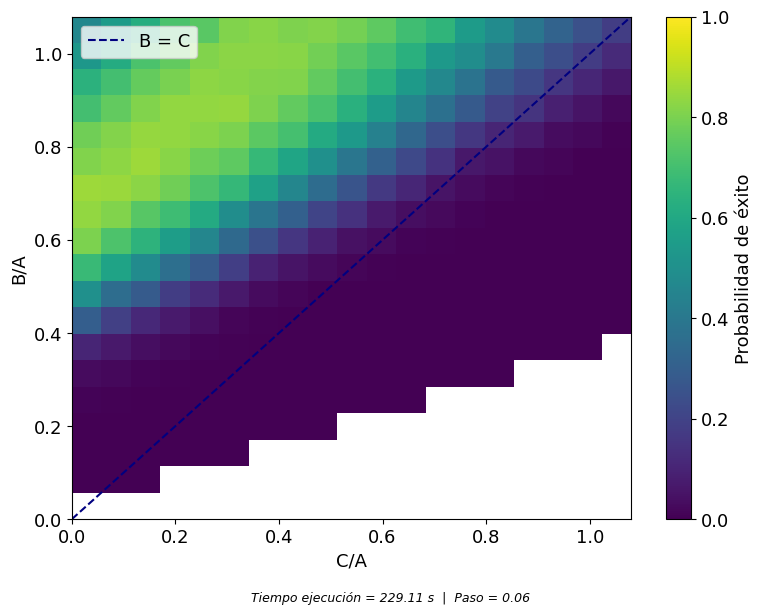

In [70]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
x0_func=x0_func_C5mod
Q_func = Q_func_C5mod
Q_exacta_func = Q_exacta_func_C5mod


sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [50]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.06
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan

            #geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
            #prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
            #resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    #plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()

A=50: 25.58 s


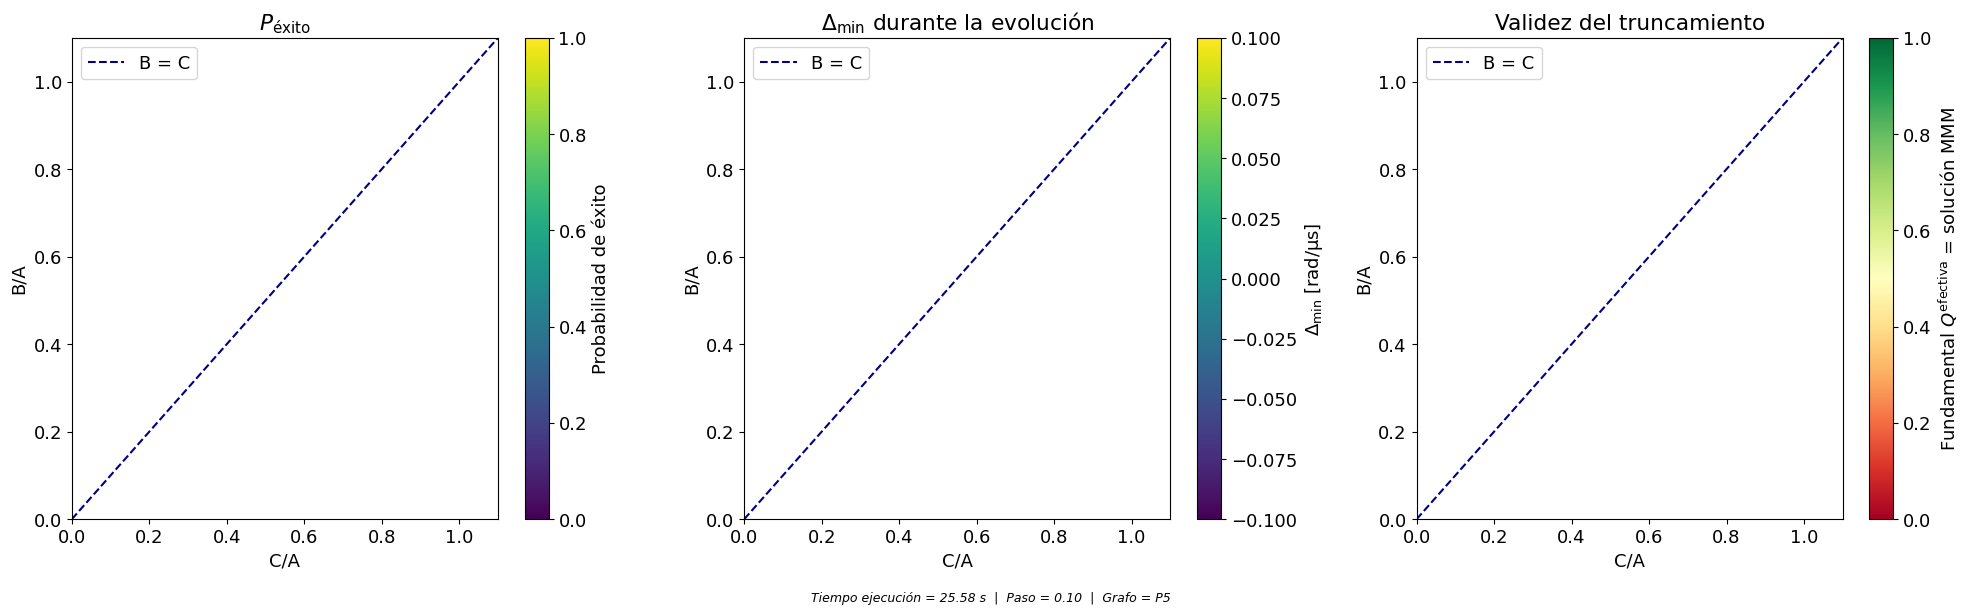

In [71]:
A = A_solucion
B = B_solucion
C = C_solucion
nombre_grafo = "P5"
x0_func = x0_func_P5
Q_func = Q_func_P5
Q_exacta_func = Q_exacta_func_P5

#### Parámetros ####
paso = 0.1
A_values = [50]
T_barrido = 5.0
n_shots = 2000

resultados_prob = {}
resultados_gap  = {}
resultados_match = {}   # 1 si fundamental de Q_efectiva coincide con solución MMM, 0 si no

for A in A_values:
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time()

    for B in B_values:
        for C in C_values:
            Q         = Q_func(A, B, C)
            Q_exacta  = Q_exacta_func(A, B, C)
            diag = -np.diag(Q)

            if np.any(diag <= 0):
                resultados_prob[(A, B, C)]  = np.nan
                resultados_gap[(A, B, C)]   = np.nan
                resultados_match[(A, B, C)] = np.nan
                continue
            try:
                # Solución MMM real (Q_exacta) y fundamental implementado (Q)
                sort_exacta   = resolucion_clasica(Q_exacta=Q_exacta, print_resultados=False)
                sort_efectiva = resolucion_clasica(Q_exacta=Q,        print_resultados=False)

                e_min_efec = sort_efectiva[0][1]
                fund_efec  = {b for b, e in sort_efectiva if e == e_min_efec}
                e_min_exac = sort_exacta[0][1]
                fund_exac  = {b for b, e in sort_exacta if e == e_min_exac}
                # ¿algún fundamental de Q_efectiva es solución MMM?
                match = 1.0 if fund_efec & fund_exac else 0.0

                geometria, coords = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_exacta, A, B, C,
                                        sweep_time=T_barrido, plot=False, n_shots=n_shots)
                delta_min, _, _ = gap_minimo_evolucion(Q, coords, A,
                                                      sweep_time=T_barrido,
                                                      n_puntos=60, plot=False)
                resultados_prob[(A, B, C)]  = prob
                resultados_gap[(A, B, C)]   = delta_min
                resultados_match[(A, B, C)] = match
            except Exception:
                resultados_prob[(A, B, C)]  = np.nan
                resultados_gap[(A, B, C)]   = np.nan
                resultados_match[(A, B, C)] = np.nan

    B_unique = sorted(set(k[1] for k in resultados_prob if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados_prob if k[0] == A))
    malla_prob  = np.array([[resultados_prob[(A, B, C)]  for C in C_unique] for B in B_unique])
    malla_gap   = np.array([[resultados_gap[(A, B, C)]   for C in C_unique] for B in B_unique])
    malla_match = np.array([[resultados_match[(A, B, C)] for C in C_unique] for B in B_unique])

    malla_prob_m  = np.ma.masked_invalid(malla_prob)
    malla_gap_m   = np.ma.masked_invalid(malla_gap)
    malla_match_m = np.ma.masked_invalid(malla_match)

    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique]

    t_total = time.time() - t0
    print(f"A={A}: {t_total:.2f} s")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # --- Mapa P_éxito ---
    im0 = axes[0].imshow(malla_prob_m, origin='lower', aspect='auto',
                         extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]],
                         vmin=0, vmax=1)
    fig.colorbar(im0, ax=axes[0], label='Probabilidad de éxito')
    axes[0].set_title('$P_\\mathrm{éxito}$')

    # --- Mapa Δ_min ---
    im1 = axes[1].imshow(malla_gap_m, origin='lower', aspect='auto',
                         extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]])
    fig.colorbar(im1, ax=axes[1], label='$\\Delta_{\\min}$ [rad/µs]')
    axes[1].set_title('$\\Delta_{\\min}$ durante la evolución')

    # --- Mapa fundamental Q_efectiva == solución MMM ---
    im2 = axes[2].imshow(malla_match_m, origin='lower', aspect='auto',
                         extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]],
                         vmin=0, vmax=1, cmap='RdYlGn')
    fig.colorbar(im2, ax=axes[2], label='Fundamental $Q^\\mathrm{efectiva}$ = solución MMM')
    axes[2].set_title('Validez del truncamiento')

    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    for ax in axes:
        ax.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
        ax.set_xlabel('C/A')
        ax.set_ylabel('B/A')
        ax.legend()

    plt.figtext(0.5, -0.02,
                f"Tiempo ejecución = {t_total:.2f} s  |  Paso = {paso:.2f}  |  Grafo = {nombre_grafo}",
                ha='center', fontsize=9, style='italic')
    plt.tight_layout()
    plt.show()